In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

In [2]:
env = gym.make("CliffWalking-v1", is_slippery=True)
env.reset()

(36, {'prob': 1})

In [3]:
obs_dim = env.observation_space.n
act_dim = env.action_space.n

Q = np.zeros((obs_dim, act_dim))
Q.shape

(48, 4)

In [4]:
NUM_EPISODES = 100000
EPSILON = np.linspace(0.9, 0.1, NUM_EPISODES)
DISCOUNT = 0.9
ALPHA = 0.1

In [5]:
reward_history = []

for i, eps in enumerate(EPSILON):
    done = False
    total_reward = 0
    trajectory = []

    old_observation, info = env.reset()
    while not done:
        action = np.argmax(Q[old_observation]) if np.random.rand() > eps else env.action_space.sample()
        new_observation, reward, terminated, truncated, info = env.step(action)

        trajectory.append([old_observation, action, reward])
        total_reward += reward
        old_observation = new_observation
        done = terminated or truncated

    trajectory = np.array(trajectory)
    reversed_rewards = trajectory[::-1, 2]
    powers = np.arange(len(reversed_rewards))
    discounts = DISCOUNT ** powers

    discounted_rewards = np.cumsum(reversed_rewards * discounts)[::-1]
    reward_history.append(total_reward)
    
    for (s, a), G in zip(trajectory[:,:2], discounted_rewards):
        Q[s, a] += ALPHA * (G - Q[s, a])

    if not (i+1) % 100:
        print(f"Episode: {i+1}/{NUM_EPISODES}, Total reward: {total_reward}")

Episode: 100/100000, Total reward: -261004
Episode: 200/100000, Total reward: -73134
Episode: 300/100000, Total reward: -11488
Episode: 400/100000, Total reward: -11185
Episode: 500/100000, Total reward: -76681
Episode: 600/100000, Total reward: -3919
Episode: 700/100000, Total reward: -51516
Episode: 800/100000, Total reward: -66668
Episode: 900/100000, Total reward: -25240
Episode: 1000/100000, Total reward: -39711
Episode: 1100/100000, Total reward: -6185
Episode: 1200/100000, Total reward: -28597
Episode: 1300/100000, Total reward: -66627
Episode: 1400/100000, Total reward: -24926
Episode: 1500/100000, Total reward: -23388
Episode: 1600/100000, Total reward: -61314
Episode: 1700/100000, Total reward: -176839
Episode: 1800/100000, Total reward: -13188
Episode: 1900/100000, Total reward: -49131
Episode: 2000/100000, Total reward: -41490
Episode: 2100/100000, Total reward: -30610
Episode: 2200/100000, Total reward: -39278
Episode: 2300/100000, Total reward: -94633
Episode: 2400/100000

<function matplotlib.pyplot.show(close=None, block=None)>

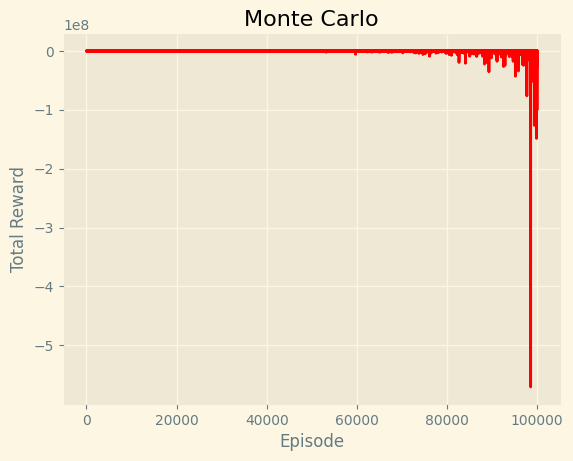

In [13]:
plt.style.use("Solarize_Light2")
plt.plot(reward_history, color="red")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Monte Carlo")
plt.show

In [12]:
np.save('../experiments/mc_stochastic_rh.npy', reward_history)
np.save('../experiments/mc_stochastic_ag.npy', Q)